In [2]:
import numpy as np
import matplotlib.pyplot as plt
from src.log_pred import logistic_predict_
from src.sigmoid import sigmoid_
from src.log_loss import log_loss_
from src.vec_log_loss import vec_log_loss_
from src.log_gradient import log_gradient
from src.logistic_regression import MyLogisticRegression as MyLR

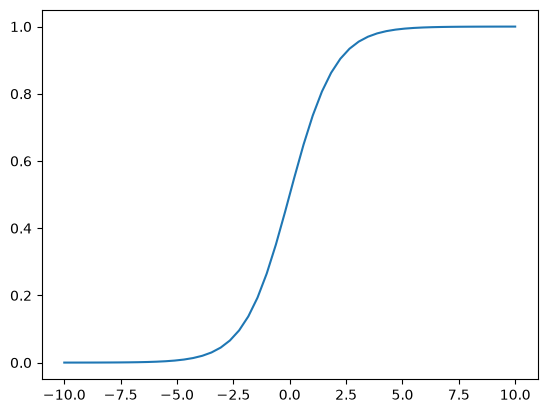

In [3]:
x = np.linspace(-10, 10).reshape(-1, 1)

plt.plot(x, sigmoid_(x))

In [4]:
x = np.array([[-4]])
assert np.allclose(sigmoid_(x), np.array([[0.01798620996209156]]))
# Example 2:
x = np.array([[2]])
assert np.allclose(sigmoid_(x), np.array([[0.8807970779778823]]))
# Example 3:
x = np.array([[-4], [2], [0]])
assert np.allclose(sigmoid_(x), np.array([[0.01798620996209156], [0.8807970779778823], [0.5]]))

In [5]:
x = np.array([4]).reshape((-1, 1))
theta = np.array([[2], [0.5]])
assert np.allclose(logistic_predict_(x, theta), np.array([[0.98201379]]))
# Example 1
x2 = np.array([[4], [7.16], [3.2], [9.37], [0.56]])
theta2 = np.array([[2], [0.5]])
assert np.allclose(logistic_predict_(x2, theta2), np.array([[0.98201379],
[0.99624161],
[0.97340301],
[0.99875204],
[0.90720705]]))
# Example 3
x3 = np.array([[0, 2, 3, 4], [2, 4, 5, 5], [1, 3, 2, 7]])
theta3 = np.array([[-2.4], [-1.5], [0.3], [-1.4], [0.7]])
assert np.allclose(logistic_predict_(x3, theta3), np.array([[0.03916572],
[0.00045262],
[0.2890505 ]]))

In [6]:
y1 = np.array([1]).reshape((-1, 1))
x1 = np.array([4]).reshape((-1, 1))
theta1 = np.array([[2], [0.5]])
y_hat1 = logistic_predict_(x1, theta1)

assert np.allclose(log_loss_(y1, y_hat1), 0.01814992791780973)

# Example 2:
y2 = np.array([[1], [0], [1], [0], [1]])
x2 = np.array([[4], [7.16], [3.2], [9.37], [0.56]])
theta2 = np.array([[2], [0.5]])
y_hat2 = logistic_predict_(x2, theta2)

assert np.allclose(log_loss_(y2, y_hat2), 2.4825011602474483)

# Example 3:
y3 = np.array([[0], [1], [1]])
x3 = np.array([[0, 2, 3, 4], [2, 4, 5, 5], [1, 3, 2, 7]])
theta3 = np.array([[-2.4], [-1.5], [0.3], [-1.4], [0.7]])
y_hat3 = logistic_predict_(x3, theta3)

assert np.allclose(log_loss_(y3, y_hat3), 2.9938533108607053)

In [7]:
y = np.array([[4], [7.16], [3.2], [9.37], [0.56]])
ones = np.ones(y.shape)
assert np.allclose((ones - y), (1 - y)) # 1 - y is not mathematically correct 1 is not a vec can't substract

In [8]:
y1 = np.array([1]).reshape((-1, 1))
x1 = np.array([4]).reshape((-1, 1))
theta1 = np.array([[2], [0.5]])
y_hat1 = logistic_predict_(x1, theta1)

assert np.allclose(vec_log_loss_(y1, y_hat1), 0.01814992791780973)

# Example 2:
y2 = np.array([[1], [0], [1], [0], [1]])
x2 = np.array([[4], [7.16], [3.2], [9.37], [0.56]])
theta2 = np.array([[2], [0.5]])
y_hat2 = logistic_predict_(x2, theta2)

assert np.allclose(vec_log_loss_(y2, y_hat2), 2.4825011602474483)

# Example 3:
y3 = np.array([[0], [1], [1]])
x3 = np.array([[0, 2, 3, 4], [2, 4, 5, 5], [1, 3, 2, 7]])
theta3 = np.array([[-2.4], [-1.5], [0.3], [-1.4], [0.7]])
y_hat3 = logistic_predict_(x3, theta3)

assert np.allclose(vec_log_loss_(y3, y_hat3), 2.9938533108607053)

In [9]:
y1 = np.array([1]).reshape((-1, 1))
x1 = np.array([4]).reshape((-1, 1))
theta1 = np.array([[2], [0.5]])
# print(f"{log_gradient(x1, y1, theta1)=}\n{np.array([[-0.01798621], [-0.07194484]])=}")
assert np.allclose(log_gradient(x1, y1, theta1), np.array([[-0.01798621], [-0.07194484]]))

# Example 2:
y2 = np.array([[1], [0], [1], [0], [1]])
x2 = np.array([[4], [7.16], [3.2], [9.37], [0.56]])
theta2 = np.array([[2], [0.5]])

assert np.allclose(log_gradient(x2, y2, theta2), np.array([[0.3715235 ], [3.25647547]]))

# Example 3:
y3 = np.array([[0], [1], [1]])
x3 = np.array([[0, 2, 3, 4], [2, 4, 5, 5], [1, 3, 2, 7]])
theta3 = np.array([[-2.4], [-1.5], [0.3], [-1.4], [0.7]])

assert np.allclose(log_gradient(x3, y3, theta3), np.array([[-0.55711039],
[-0.90334809],
[-2.01756886],
[-2.10071291],
[-3.27257351]]))

In [10]:
import math

X = np.array([[1., 1., 2., 3.], [5., 8., 13., 21.], [3., 5., 9., 14.]])
Y = np.array([[1], [0], [1]])
thetas = np.array([[2], [0.5], [7.1], [-4.3], [2.09]])
mylr = MyLR(thetas)
# Example 0:
y_hat = mylr.predict_(X)
assert np.allclose(y_hat, np.array([[0.99930437],
[1. ],
[1. ]]))
# Example 1:
assert math.isclose(mylr.loss_(Y, y_hat), 11.513157421577002, rel_tol=1e-4)
# Example 2:
mylr.fit_(X, Y)
assert np.allclose(mylr.thetas, np.array([[ 2.11826435],
[ 0.10154334],
[ 6.43942899],
[-5.10817488],
[ 0.6212541 ]]))
# Example 3:
y_hat2 = mylr.predict_(X)
assert np.allclose(y_hat2, np.array([[0.57606717],
[0.68599807],
[0.06562156]]))
# Example 4:
assert math.isclose(mylr.loss_(Y, y_hat2), 1.4779126923052268, rel_tol=1e-4)

training on zipcode=1
eval predictions: 98.4375% accurate.
(63 good predictions out of 64).


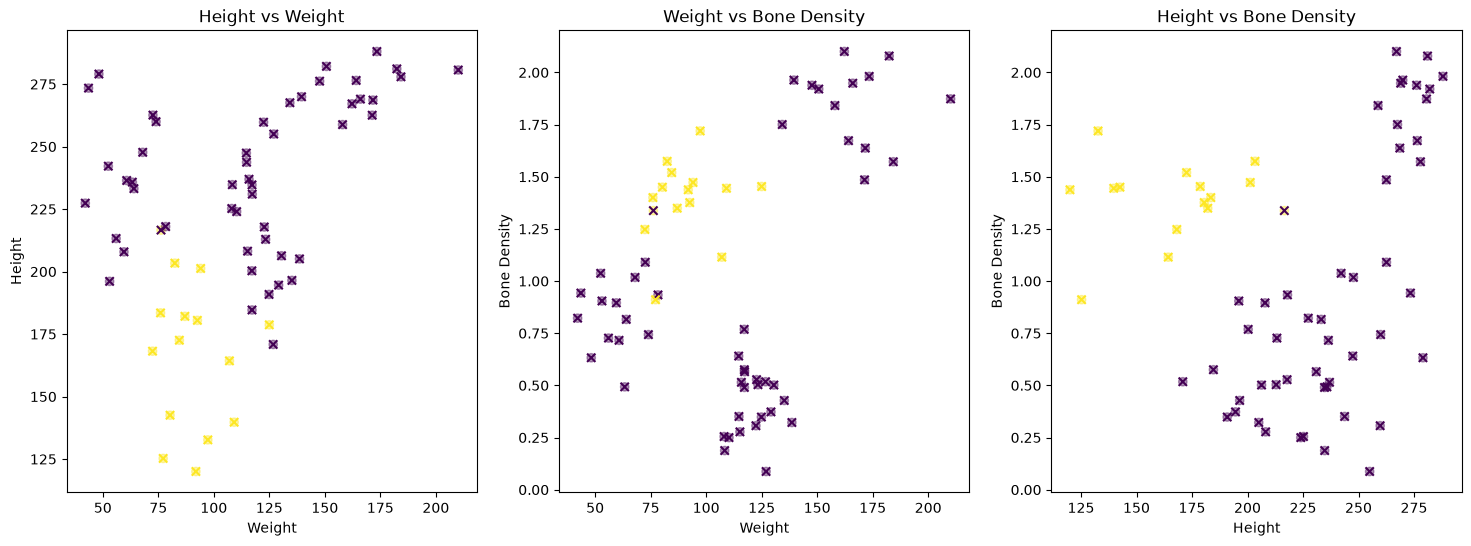

In [11]:
from src.mono_log import mono_log_

mono_log_(zipcode=1)

eval predictions: 97.91666666666667% accurate.
(94 good predictions out of 96).


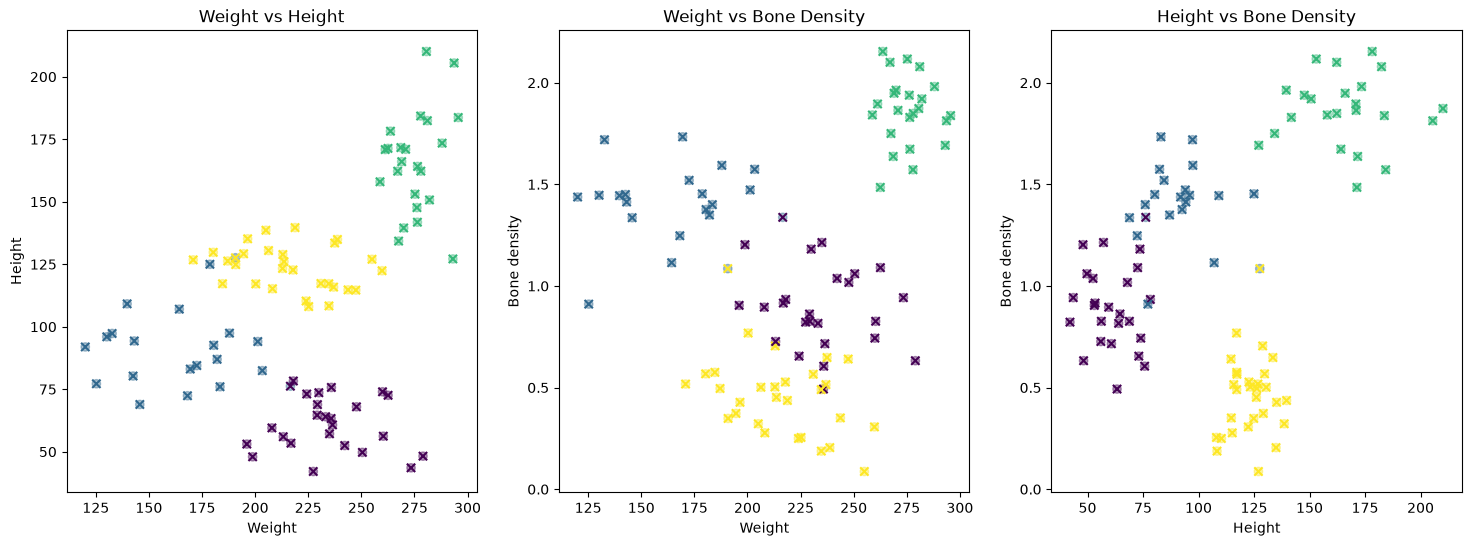

In [12]:
from src.multi_log import one_vs_all

one_vs_all()

In [13]:
import math
from src.other_metrics import accuracy_score_, precision_score_, recall_score_, f1_score_
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_hat = np.array([1, 1, 0, 1, 0, 0, 1, 1]).reshape((-1, 1))
y = np.array([1, 0, 0, 1, 0, 1, 0, 0]).reshape((-1, 1))

print(f"sklearn {accuracy_score(y, y_hat)=}\nmy {accuracy_score_(y, y_hat)=}\n")
assert math.isclose(accuracy_score_(y, y_hat), 0.5)


print(f"sklearn {precision_score(y, y_hat)=}\nmy {precision_score_(y, y_hat)=}\n")
assert math.isclose(precision_score_(y, y_hat), 0.4)


print(f"sklearn {recall_score(y, y_hat)=}\nmy {recall_score_(y, y_hat)=}\n")
assert math.isclose(recall_score_(y, y_hat), 0.6666666666666666)


print(f"sklearn {f1_score(y, y_hat)=}\nmy {f1_score_(y, y_hat)=}")
assert math.isclose(f1_score_(y, y_hat), 0.5)

y_hat = np.array(['norminet', 'dog', 'norminet', 'norminet', 'dog', 'dog', 'dog', 'dog'])
y = np.array(['dog', 'dog', 'norminet', 'norminet', 'dog', 'norminet', 'dog', 'norminet'])

print(f"sklearn {accuracy_score(y, y_hat)=}\nmy {accuracy_score_(y, y_hat)=}\n")
assert math.isclose(accuracy_score_(y, y_hat), 0.625)


print(f"sklearn {precision_score(y, y_hat, pos_label='dog')=}\nmy {precision_score_(y, y_hat, pos_label='dog')=}\n")
assert math.isclose(precision_score_(y, y_hat, pos_label='dog'), 0.6)


print(f"sklearn {recall_score(y, y_hat, pos_label='dog')=}\nmy {recall_score_(y, y_hat, pos_label='dog')=}\n")
assert math.isclose(recall_score_(y, y_hat, pos_label='dog'), 0.75)


print(f"sklearn {f1_score(y, y_hat, pos_label='dog')=}\nmy {f1_score_(y, y_hat, pos_label='dog')=}")
assert math.isclose(f1_score_(y, y_hat, pos_label='dog'), 0.6666666666666665)

y_hat = np.array(['norminet', 'dog', 'norminet', 'norminet', 'dog', 'dog', 'dog', 'dog'])
y = np.array(['dog', 'dog', 'norminet', 'norminet', 'dog', 'norminet', 'dog', 'norminet'])

print(f"sklearn {precision_score(y, y_hat, pos_label='norminet')=}\nmy {precision_score_(y, y_hat, pos_label='norminet')=}\n")
assert math.isclose(precision_score_(y, y_hat, pos_label='norminet'), 0.6666666666666666)

print(f"sklearn {recall_score(y, y_hat, pos_label='norminet')=}\nmy {recall_score_(y, y_hat, pos_label='norminet')=}\n")
assert math.isclose(recall_score_(y, y_hat, pos_label='norminet'), 0.5)

print(f"sklearn {f1_score(y, y_hat, pos_label='norminet')=}\nmy {f1_score_(y, y_hat, pos_label='norminet')=}")
assert math.isclose(f1_score_(y, y_hat, pos_label='norminet'), 0.5714285714285715)

sklearn accuracy_score(y, y_hat)=0.5
my accuracy_score_(y, y_hat)=0.5

sklearn precision_score(y, y_hat)=0.4
my precision_score_(y, y_hat)=0.4

sklearn recall_score(y, y_hat)=0.6666666666666666
my recall_score_(y, y_hat)=0.6666666666666666

sklearn f1_score(y, y_hat)=0.5
my f1_score_(y, y_hat)=0.5
sklearn accuracy_score(y, y_hat)=0.625
my accuracy_score_(y, y_hat)=0.625

sklearn precision_score(y, y_hat, pos_label='dog')=0.6
my precision_score_(y, y_hat, pos_label='dog')=0.6

sklearn recall_score(y, y_hat, pos_label='dog')=0.75
my recall_score_(y, y_hat, pos_label='dog')=0.75

sklearn f1_score(y, y_hat, pos_label='dog')=0.6666666666666666
my f1_score_(y, y_hat, pos_label='dog')=0.6666666666666665
sklearn precision_score(y, y_hat, pos_label='norminet')=0.6666666666666666
my precision_score_(y, y_hat, pos_label='norminet')=0.6666666666666666

sklearn recall_score(y, y_hat, pos_label='norminet')=0.5
my recall_score_(y, y_hat, pos_label='norminet')=0.5

sklearn f1_score(y, y_hat, pos_label

In [14]:
from src.confusion_matrix import confusion_matrix_
from sklearn.metrics import confusion_matrix

y_hat = np.array([['norminet'], ['dog'], ['norminet'], ['norminet'], ['dog'], ['bird']])
y = np.array([['dog'], ['dog'], ['norminet'], ['norminet'], ['dog'], ['norminet']])

print(f"sklearn {confusion_matrix(y, y_hat)=}\nmy {confusion_matrix_(y, y_hat)=}\n")
assert np.allclose(confusion_matrix_(y, y_hat), np.array([[0, 0, 0],
                                                            [0, 2, 1],
                                                            [1, 0, 2]]))

print(f"sklearn {confusion_matrix(y, y_hat, labels=['dog', 'norminet'])=}\nmy {confusion_matrix_(y, y_hat, labels=['dog', 'norminet'])=}")
assert np.allclose(confusion_matrix_(y, y_hat, labels=['dog', 'norminet']), np.array([[2, 1],
                                                                                       [0, 2]]))

sklearn confusion_matrix(y, y_hat)=array([[0, 0, 0],
       [0, 2, 1],
       [1, 0, 2]])
my confusion_matrix_(y, y_hat)=array([[0., 0., 0.],
       [0., 2., 1.],
       [1., 0., 2.]])

sklearn confusion_matrix(y, y_hat, labels=['dog', 'norminet'])=array([[2, 1],
       [0, 2]])
my confusion_matrix_(y, y_hat, labels=['dog', 'norminet'])=array([[2., 1.],
       [0., 2.]])
